# CNN Algoritma Akışı

Bu not defteri, hafta10/archive altındaki gerçek bir görüntü üzerinden CNN'in temel adımlarını gösterir:
1. Görüntü giriş olarak alınır.
2. Convolution katmanında filtre/kernel ile kenar ve desenler çıkarılır.
3. ReLU ile negatif değerler sıfırlanır.
4. Max pooling ile uzamsal boyut küçültülür.
5. Son özellik haritası flatten edilerek düzleştirilmiş vektöre çevrilir.

Amaç, seçilen gerçek bir görüntünün son düzleştirilmiş veri vektörüne kadar nasıl dönüştüğünü adım adım görmek.

## CNN'de Ne Oluyor?

Bu örnekte `hafta10/archive/cats_set` ve `hafta10/archive/dogs_set` altından rastgele seçilen gerçek bir görüntü kullanacağız. Akış şu şekilde ilerleyecek:
- Görüntü önce RGB olarak açılır, sonra CNN işlemleri için gri tona çevrilir ve sabit boyuta getirilir.
- `kernel/filter`: 3x3 çekirdek ile özellik çıkarılır.
- `convolution`: çekirdeği görüntü üzerinde kaydırıp noktasal çarpım alırız.
- `ReLU`: negatif değerleri sıfırlarız.
- `max pooling`: en güçlü yanıtları tutup boyutu küçültürüz.
- `flatten`: son özellik haritasını tek boyutlu vektöre çeviririz.

Convolution işlemi matematiksel olarak şu fikre dayanır:

$$
Y(i,j) = \sum_{m=0}^{k-1}\sum_{n=0}^{k-1} X(i+m, j+n) \cdot K(m,n)
$$

Burada `X` giriş görüntüsü, `K` kernel ve `Y` çıkış özellik haritasıdır.

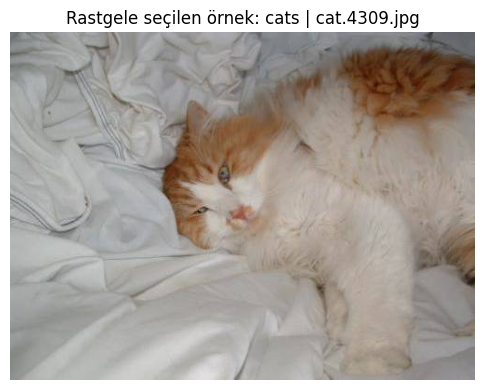

Seçilen dosya: /home/onc/workspace/dersler/2526/ileri_programlama/hafta10/archive/cats_set/cat.4309.jpg
Görüntü boyutu: (374, 500, 3)


In [3]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

np.set_printoptions(precision=2, suppress=True)

base_dir = Path('/home/onc/workspace/dersler/2526/ileri_programlama/hafta10/archive')
image_paths = list(base_dir.glob('cats_set/*.jpg')) + list(base_dir.glob('dogs_set/*.jpg'))
selected_image_path = random.choice(image_paths)
selected_label = selected_image_path.parent.name.replace('_set', '')

original_image = Image.open(selected_image_path).convert('RGB')
original_array = np.array(original_image)

plt.figure(figsize=(6, 6))
plt.imshow(original_array)
plt.title(f'Rastgele seçilen örnek: {selected_label} | {selected_image_path.name}')
plt.axis('off')
plt.show()

print('Seçilen dosya:', selected_image_path)
print('Görüntü boyutu:', original_array.shape)

## Adım 2: CNN Dönüşümleri

Bu hücrede seçilen gerçek görüntü üzerinde sırayla convolution, ReLU, pooling ve flatten işlemleri yapılır. Her aşamada resmin ya da özellik haritasının görsel çıktısı gösterilir.

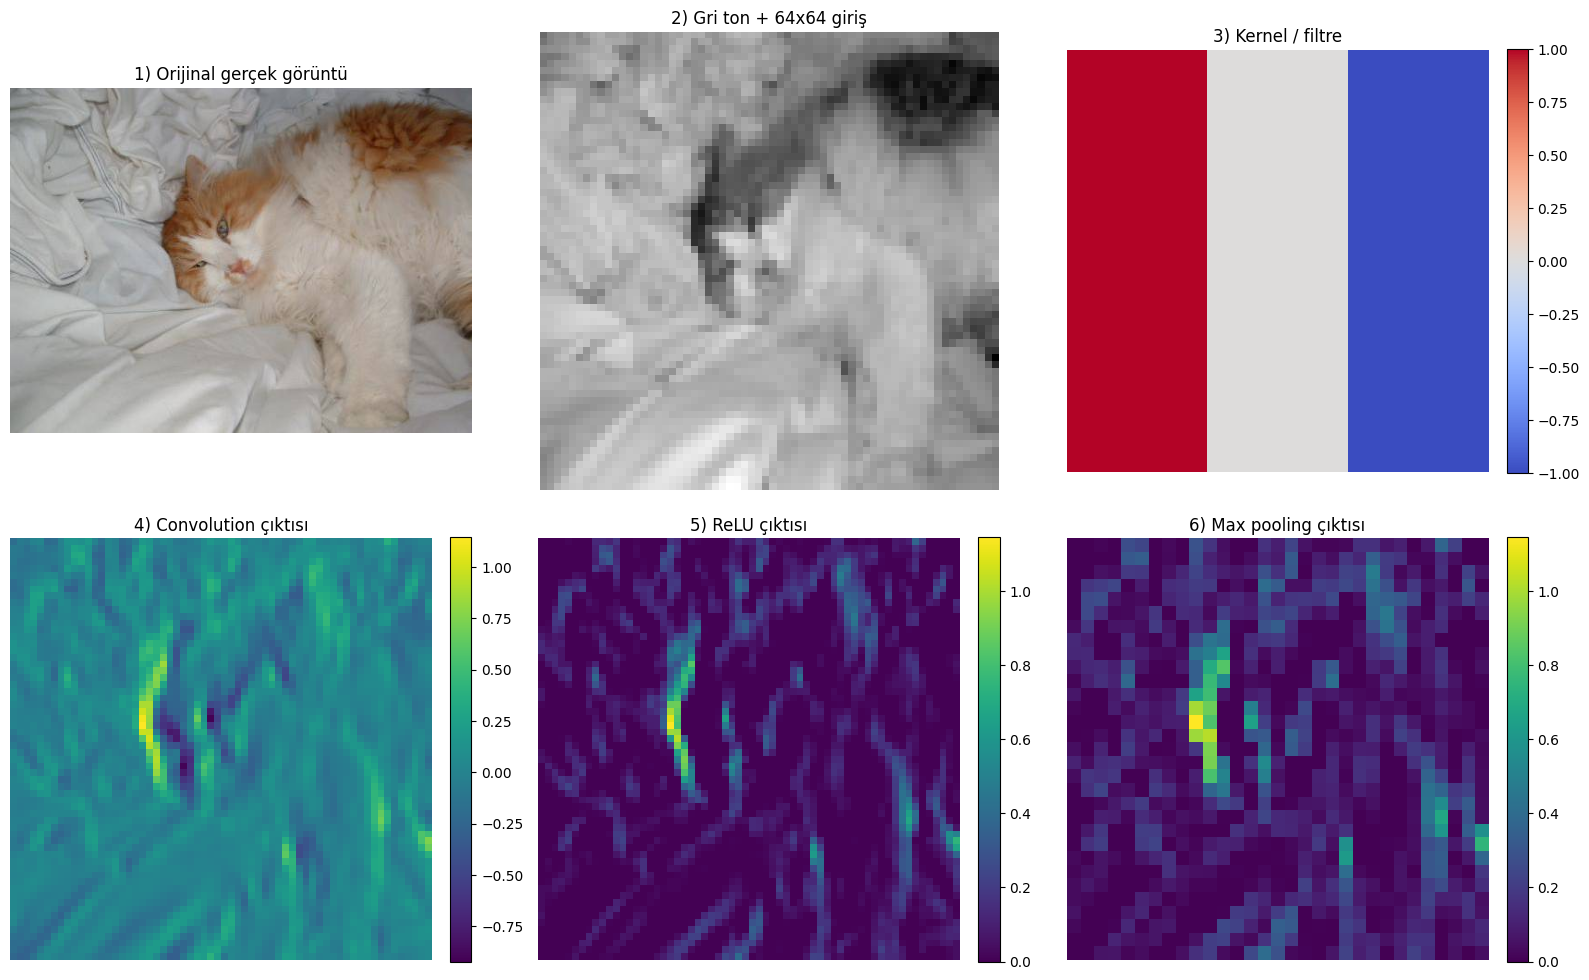

Convolution sonucu şekil: (62, 62)
ReLU sonucu şekil: (62, 62)
Pooling sonucu şekil: (31, 31)

Flatten edilmiş son vektör:
[0.   0.   0.02 0.   0.27 0.24 0.   0.03 0.   0.29 0.17 0.04 0.   0.
 0.16 0.1  0.24 0.05 0.02 0.02 0.02 0.16 0.16 0.07 0.1  0.   0.08 0.37
 0.22 0.   0.   0.   0.   0.   0.   0.31 0.34 0.   0.02 0.   0.27 0.11
 0.05 0.   0.04 0.12 0.08 0.33 0.01 0.09 0.04 0.18 0.12 0.35 0.2  0.17
 0.02 0.02 0.15 0.04 0.   0.   0.   0.   0.05 0.04 0.19 0.18 0.   0.05
 0.12 0.23 0.15 0.1  0.06 0.09 0.28 0.16 0.31 0.   0.13 0.12 0.23 0.21
 0.47 0.2  0.02 0.08 0.   0.16 0.   0.22 0.06 0.   0.18 0.2  0.24 0.
 0.09 0.   0.15 0.16 0.2  0.19 0.   0.04 0.   0.4  0.33 0.05 0.05 0.21
 0.2  0.25 0.2  0.43 0.28 0.05 0.18 0.05 0.08 0.   0.3  0.   0.   0.25
 0.27 0.06 0.02 0.04 0.   0.12 0.15 0.18 0.05 0.09 0.13 0.08 0.29 0.11
 0.18 0.18 0.17 0.25 0.   0.05 0.38 0.35 0.32 0.24 0.   0.13 0.09 0.22
 0.13 0.   0.25 0.14 0.02 0.02 0.06 0.18 0.   0.14 0.13 0.03 0.2  0.11
 0.09 0.24 0.21 0.24 0.12 0.0

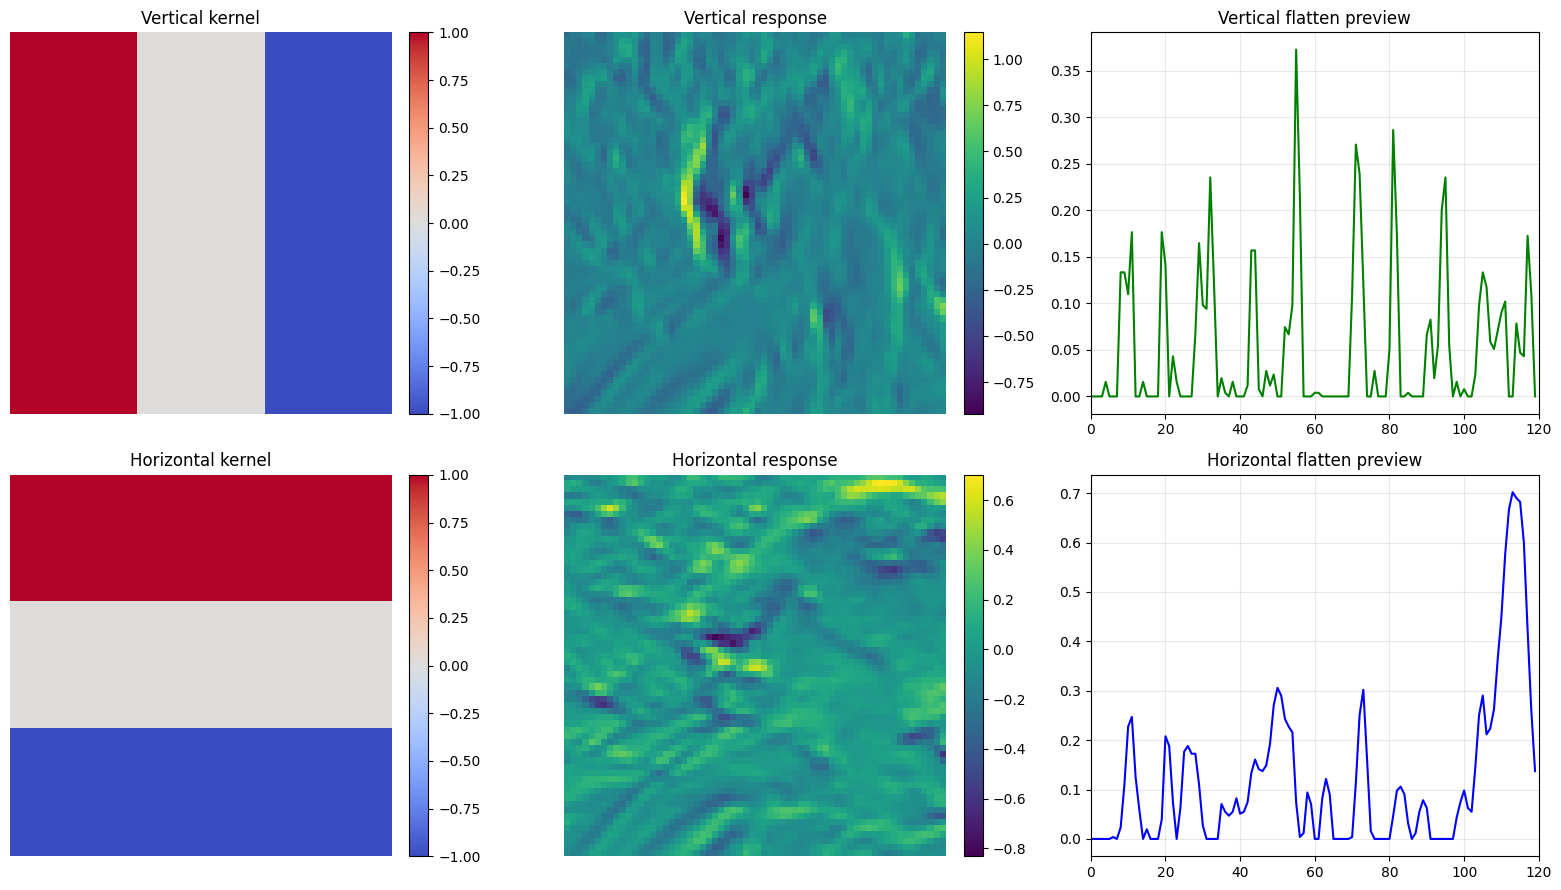

Vertical flatten uzunluğu: 3844
Horizontal flatten uzunluğu: 3844
Vertical flatten ilk değerler: [0.   0.   0.   0.   0.02 0.   0.   0.   0.13 0.13 0.11 0.18 0.   0.
 0.02 0.   0.   0.   0.   0.18]
Horizontal flatten ilk değerler: [0.   0.   0.   0.   0.   0.   0.   0.   0.02 0.11 0.23 0.25 0.13 0.06
 0.   0.02 0.   0.   0.   0.04]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageOps


def conv2d_valid(image, kernel):
    image = np.array(image, dtype=float)
    kernel = np.array(kernel, dtype=float)
    out_h = image.shape[0] - kernel.shape[0] + 1
    out_w = image.shape[1] - kernel.shape[1] + 1
    output = np.zeros((out_h, out_w), dtype=float)

    for i in range(out_h):
        for j in range(out_w):
            window = image[i:i + kernel.shape[0], j:j + kernel.shape[1]]
            output[i, j] = np.sum(window * kernel)
    return output


def max_pool2d(feature_map, pool_size=2, stride=2):
    feature_map = np.array(feature_map, dtype=float)
    out_h = (feature_map.shape[0] - pool_size) // stride + 1
    out_w = (feature_map.shape[1] - pool_size) // stride + 1
    output = np.zeros((out_h, out_w), dtype=float)

    for i in range(out_h):
        for j in range(out_w):
            window = feature_map[i * stride:i * stride + pool_size, j * stride:j * stride + pool_size]
            output[i, j] = np.max(window)
    return output


# Seçilen gerçek görüntüyü CNN için sabit boyuta indir ve gri tona çevir
cnn_size = (64, 64)
cnn_image = ImageOps.grayscale(original_image).resize(cnn_size)
cnn_array = np.array(cnn_image, dtype=float) / 255.0

# Kenar/şekil yakalayan örnek kernel
vertical_kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
], dtype=float)

conv_output = conv2d_valid(cnn_array, vertical_kernel)
relu_output = np.maximum(0, conv_output)
pool_output = max_pool2d(relu_output, pool_size=2, stride=2)
flat_output = pool_output.flatten()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

axes[0].imshow(original_array)
axes[0].set_title('1) Orijinal gerçek görüntü')
axes[0].axis('off')

axes[1].imshow(cnn_array, cmap='gray')
axes[1].set_title('2) Gri ton + 64x64 giriş')
axes[1].axis('off')

im2 = axes[2].imshow(vertical_kernel, cmap='coolwarm')
axes[2].set_title('3) Kernel / filtre')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(conv_output, cmap='viridis')
axes[3].set_title('4) Convolution çıktısı')
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

im4 = axes[4].imshow(relu_output, cmap='viridis')
axes[4].set_title('5) ReLU çıktısı')
axes[4].axis('off')
plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

im5 = axes[5].imshow(pool_output, cmap='viridis')
axes[5].set_title('6) Max pooling çıktısı')
axes[5].axis('off')
plt.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print('Convolution sonucu şekil:', conv_output.shape)
print('ReLU sonucu şekil:', relu_output.shape)
print('Pooling sonucu şekil:', pool_output.shape)
print('\nFlatten edilmiş son vektör:')
print(flat_output)
print('\nFlatten edilmiş veri uzunluğu:', len(flat_output))

print('\n--- İkinci kernel karşılaştırması ---')
horizontal_kernel = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1],
], dtype=float)

vertical_response = conv2d_valid(cnn_array, vertical_kernel)
horizontal_response = conv2d_valid(cnn_array, horizontal_kernel)
vertical_flat = np.maximum(0, vertical_response).flatten()
horizontal_flat = np.maximum(0, horizontal_response).flatten()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

im0 = axes[0].imshow(vertical_kernel, cmap='coolwarm')
axes[0].set_title('Vertical kernel')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(vertical_response, cmap='viridis')
axes[1].set_title('Vertical response')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].plot(vertical_flat[:120], color='green')
axes[2].set_title('Vertical flatten preview')
axes[2].set_xlim(0, min(120, len(vertical_flat) - 1))
axes[2].grid(alpha=0.3)

im2 = axes[3].imshow(horizontal_kernel, cmap='coolwarm')
axes[3].set_title('Horizontal kernel')
axes[3].axis('off')
plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)

im3 = axes[4].imshow(horizontal_response, cmap='viridis')
axes[4].set_title('Horizontal response')
axes[4].axis('off')
plt.colorbar(im3, ax=axes[4], fraction=0.046, pad=0.04)

axes[5].plot(horizontal_flat[:120], color='blue')
axes[5].set_title('Horizontal flatten preview')
axes[5].set_xlim(0, min(120, len(horizontal_flat) - 1))
axes[5].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Vertical flatten uzunluğu:', len(vertical_flat))
print('Horizontal flatten uzunluğu:', len(horizontal_flat))
print('Vertical flatten ilk değerler:', vertical_flat[:20])
print('Horizontal flatten ilk değerler:', horizontal_flat[:20])